# A/B Test Analysis: Designing and Reading an Experiment Correctly

A worked conversion experiment done the disciplined way: decide the sample size **before** looking
at data, analyze with a confidence interval and effect size (not just a p-value), make an explicit
ship decision, and then demonstrate the two classic ways teams fool themselves, **peeking** and
**multiple comparisons**.

**Scenario.** A checkout redesign. Baseline conversion is **12%**. We will ship only if the new
design lifts conversion by at least **1.5 percentage points** (to 13.5%), our minimum detectable
effect and also our practical-significance bar.

The stats live in a small tested module, `src/abtest/`; this notebook uses it.


In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt
from abtest import (sample_size_two_proportions, two_proportion_test, cohens_h,
                    simulate_peeking, familywise_error, bonferroni_alpha)

TEAL="#0e7c86"; TEAL_DEEP="#0a5b63"; SIGNAL="#e23b52"; INK="#12212a"; MUTED="#536068"; NEUTRAL="#aebabf"
plt.rcParams.update({"figure.dpi":110,"axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.alpha":.25,"font.size":11,"axes.edgecolor":"#d0d9db"})

BASELINE = 0.12       # control conversion rate
MDE_ABS  = 0.015      # minimum detectable effect (absolute pp) = practical-significance bar
ALPHA    = 0.05
POWER    = 0.80
print(f"baseline={BASELINE:.0%}  MDE=+{MDE_ABS:.1%}  alpha={ALPHA}  power={POWER:.0%}")

baseline=12%  MDE=+1.5%  alpha=0.05  power=80%


## 1. Design first: how big must the experiment be?

Sample size is decided up front from the baseline, the effect we care about (MDE), the
significance level, and the power. Deciding this *after* seeing data is how you end up with an
underpowered test you can't interpret.

In [2]:
n_per_arm = sample_size_two_proportions(BASELINE, MDE_ABS, alpha=ALPHA, power=POWER)
print(f"required sample size: {n_per_arm:,} per arm  ({2*n_per_arm:,} total)")
print("Interpretation: with this n, if the true lift is +1.5pp we have an 80% chance of")
print("detecting it at the 5% significance level.")

required sample size: 7,758 per arm  (15,516 total)
Interpretation: with this n, if the true lift is +1.5pp we have an 80% chance of
detecting it at the 5% significance level.


## 2. Run and analyze the experiment

We simulate the experiment with a **known** true treatment rate of 13.8% (a real effect, slightly
above our MDE), so we can confirm the analysis recovers the truth. In a real test this data would
come from the logs. We report the lift, its 95% confidence interval, the p-value, and the effect
size, never a bare p-value.

In [3]:
rng = np.random.default_rng(7)
p_c_true, p_t_true = 0.12, 0.138
control   = rng.random(n_per_arm) < p_c_true
treatment = rng.random(n_per_arm) < p_t_true

res = two_proportion_test(control.sum(), n_per_arm, treatment.sum(), n_per_arm, alpha=ALPHA)
print(f"control    conversion: {res.rate_control:.3%}  ({control.sum():,}/{n_per_arm:,})")
print(f"treatment  conversion: {res.rate_treatment:.3%}  ({treatment.sum():,}/{n_per_arm:,})")
print(f"absolute lift: {res.abs_diff:+.3%}   relative lift: {res.rel_lift:+.1%}")
print(f"95% CI on the absolute lift: [{res.ci_low:+.3%}, {res.ci_high:+.3%}]")
print(f"p-value: {res.p_value:.4g}    Cohen's h: {cohens_h(res.rate_control, res.rate_treatment):.3f}")
print(f"statistically significant: {res.significant}")

control    conversion: 11.872%  (921/7,758)
treatment  conversion: 13.534%  (1,050/7,758)
absolute lift: +1.663%   relative lift: +14.0%
95% CI on the absolute lift: [+0.615%, +2.710%]
p-value: 0.001871    Cohen's h: 0.050
statistically significant: True


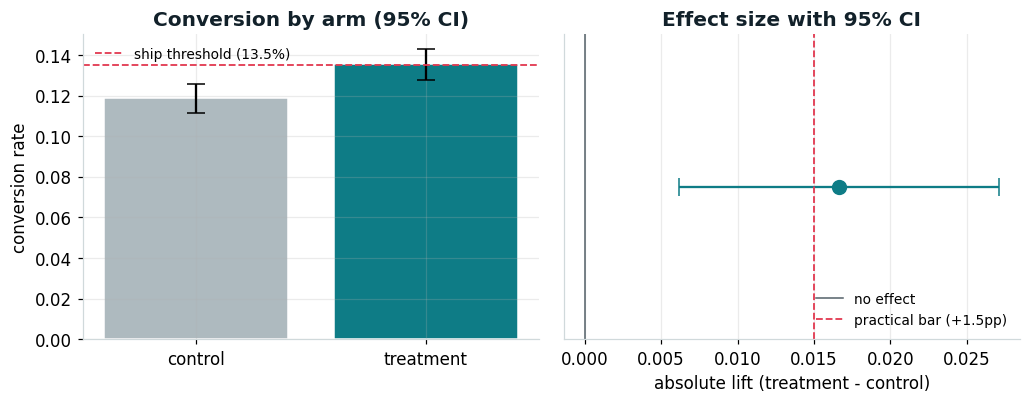

In [4]:
# Visualize the two rates with 95% CIs
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
rates = [res.rate_control, res.rate_treatment]
errs = [1.96*np.sqrt(p*(1-p)/n_per_arm) for p in rates]
ax[0].bar(["control","treatment"], rates, yerr=errs, capsize=6,
          color=[NEUTRAL, TEAL], edgecolor="white")
ax[0].axhline(BASELINE+MDE_ABS, color=SIGNAL, ls="--", lw=1.2, label="ship threshold (13.5%)")
ax[0].set_ylabel("conversion rate"); ax[0].set_title("Conversion by arm (95% CI)", color=INK, fontweight="bold")
ax[0].legend(frameon=False, fontsize=9)

# the difference and its CI vs the decision thresholds
ax[1].errorbar([res.abs_diff], [0], xerr=[[res.abs_diff-res.ci_low],[res.ci_high-res.abs_diff]],
               fmt="o", color=TEAL, capsize=6, ms=9)
ax[1].axvline(0, color=MUTED, lw=1, label="no effect")
ax[1].axvline(MDE_ABS, color=SIGNAL, ls="--", lw=1.2, label="practical bar (+1.5pp)")
ax[1].set_yticks([]); ax[1].set_xlabel("absolute lift (treatment - control)")
ax[1].set_title("Effect size with 95% CI", color=INK, fontweight="bold")
ax[1].legend(frameon=False, fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

## 3. The decision: statistical vs practical significance

Two different questions, and you need both:

- **Statistically significant?** The 95% CI on the lift excludes zero, so yes, the effect is real.
- **Practically significant?** The point estimate clears our +1.5pp ship bar, though notice the
  *lower* CI bound sits below it, the effect is real but its size is still a little uncertain.

Because the estimate clears the bar and the interval excludes zero, the call is **ship**, with a
note that a slightly larger sample would tighten the estimate. A p-value alone would have told us
"significant" and hidden all of that nuance.

## 4. Pitfall #1: peeking (optional stopping)

The most common way to manufacture a false positive: watch the test live and stop the moment it
looks significant. Each peek is another chance for noise to cross the line. Here is an **A/A test**
(no true difference): a single fixed-n test holds the false-positive rate near 5%, but "peek and
stop when significant" inflates it badly, and it gets worse the more you peek.

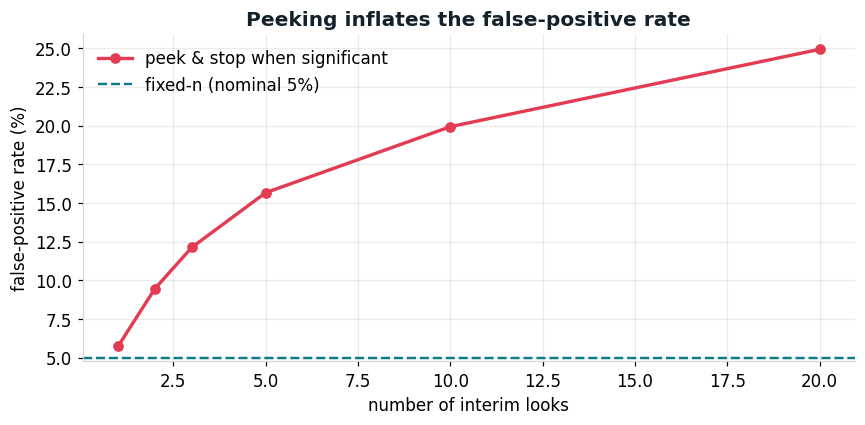

1 look (fixed): 5.7%   |   20 looks: 24.9%


In [5]:
looks_grid = [1, 2, 3, 5, 10, 20]
fixed_fp, peek_fp = [], []
for L in looks_grid:
    f, p = simulate_peeking(BASELINE, n_total=6000, n_looks=L, alpha=ALPHA, n_sims=1500, seed=1)
    fixed_fp.append(f); peek_fp.append(p)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(looks_grid, [100*x for x in peek_fp], color=SIGNAL, marker="o", lw=2.2, label="peek & stop when significant")
ax.axhline(100*ALPHA, color=TEAL, ls="--", lw=1.6, label="fixed-n (nominal 5%)")
ax.set_xlabel("number of interim looks"); ax.set_ylabel("false-positive rate (%)")
ax.set_title("Peeking inflates the false-positive rate", color=INK, fontweight="bold")
ax.legend(frameon=False); plt.tight_layout(); plt.show()
print(f"1 look (fixed): {peek_fp[0]:.1%}   |   20 looks: {peek_fp[-1]:.1%}")

The fix: fix the sample size in advance and test once, or use a method built for continuous
monitoring (sequential testing / always-valid confidence intervals with alpha-spending). What you
cannot do is use a fixed-n test and stop whenever it looks good.

## 5. Pitfall #2: multiple comparisons

Test enough metrics or segments and something will look significant by chance. With `k` independent
tests at 5%, the probability of at least one false positive is `1 - 0.95^k`, which climbs fast. The
Bonferroni correction tightens the per-test threshold to `alpha/k` to hold the overall rate at 5%.

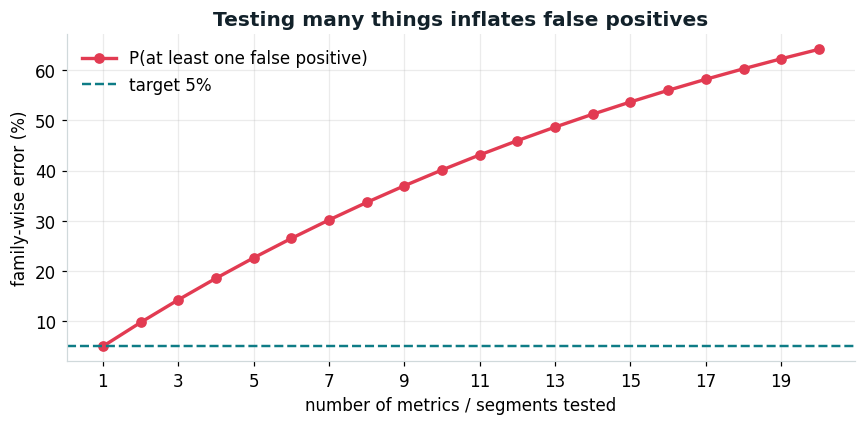

k= 5: P(>=1 false positive)=23%  ->  Bonferroni per-test alpha=0.0100
k=10: P(>=1 false positive)=40%  ->  Bonferroni per-test alpha=0.0050
k=20: P(>=1 false positive)=64%  ->  Bonferroni per-test alpha=0.0025


In [6]:
ks = np.arange(1, 21)
fwer = [100*familywise_error(k) for k in ks]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, fwer, color=SIGNAL, marker="o", lw=2.2, label="P(at least one false positive)")
ax.axhline(5, color=TEAL, ls="--", lw=1.6, label="target 5%")
ax.set_xlabel("number of metrics / segments tested"); ax.set_ylabel("family-wise error (%)")
ax.set_title("Testing many things inflates false positives", color=INK, fontweight="bold")
ax.set_xticks(ks[::2]); ax.legend(frameon=False); plt.tight_layout(); plt.show()
for k in (5, 10, 20):
    print(f"k={k:>2}: P(>=1 false positive)={familywise_error(k):.0%}  ->  Bonferroni per-test alpha={bonferroni_alpha(k):.4f}")

## Takeaways

- **Design before you analyze.** The sample size comes from the effect you care about, not from
  when the data happens to look good.
- **Report the interval and the effect size, not a bare p-value.** "Significant" and "big enough to
  ship" are different questions.
- **Don't peek** with a fixed-n test, and **correct for multiple comparisons** when you test many
  things. Both pitfalls turn noise into false wins, and both are shown here on data with no real
  effect.

Everything statistical here comes from the tested `abtest` module in `../src/`.